In [94]:
from textwrap import wrap

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

In [95]:
# Load all Olist tables
def load_olist_data(data_dir):
    """Load all Olist CSV files into a dictionary of DataFrames."""

    tables = {
        'orders': 'olist_orders_dataset.csv',
        'order_items': 'olist_order_items_dataset.csv',
        'customers': 'olist_customers_dataset.csv',
        'products': 'olist_products_dataset.csv',
        'sellers': 'olist_sellers_dataset.csv',
        'payments': 'olist_order_payments_dataset.csv',
        'reviews': 'olist_order_reviews_dataset.csv',
        'geolocation': 'olist_geolocation_dataset.csv',
        'category_translation': 'product_category_name_translation.csv'
    }

    # Date columns to parse
    date_cols = {
        'orders': ['order_purchase_timestamp', 'order_approved_at',
                   'order_delivered_carrier_date', 'order_delivered_customer_date',
                   'order_estimated_delivery_date'],
        'order_items': ['shipping_limit_date'],
        'reviews': ['review_creation_date', 'review_answer_timestamp']
    }

    data = {}
    for name, filename in tables.items():
        # filepath = os.path.join(data_dir, filename)
        filepath = data_dir + "/" + filename
        parse_dates = date_cols.get(name, None)
        data[name] = pd.read_csv(filepath, parse_dates=parse_dates)
        print(f"Loaded {name}: {data[name].shape[0]:,} rows × {data[name].shape[1]} cols")

    return data

# Load data
DATA_DIR = './raw/Olist'
olist = load_olist_data(DATA_DIR)

Loaded orders: 99,441 rows × 8 cols
Loaded order_items: 112,650 rows × 7 cols
Loaded customers: 99,441 rows × 5 cols
Loaded products: 32,951 rows × 9 cols
Loaded sellers: 3,095 rows × 4 cols
Loaded payments: 103,886 rows × 5 cols
Loaded reviews: 99,224 rows × 7 cols
Loaded geolocation: 1,000,163 rows × 5 cols
Loaded category_translation: 71 rows × 2 cols


In [96]:
def schema_summary(data_dict):
    """Generate a summary of all tables."""
    summary = []
    for name, df in data_dict.items():
        summary.append({
            'Table': name,
            'Rows': f"{df.shape[0]:,}",
            'Columns': df.shape[1],
            'Memory (MB)': f"{df.memory_usage(deep=True).sum() / 1e6:.2f}",
            'Columns List': ', '.join(df.columns[:5]) + ('...' if len(df.columns) > 5 else '')
        })
    return pd.DataFrame(summary)

schema_summary(olist)

,Table,Rows,Columns,Memory (MB),Columns List
0,orders,"99,441",8,25.85,"order_id, customer_id, order_status, order_pur..."
1,order_items,"112,650",7,30.98,"order_id, order_item_id, product_id, seller_id..."
2,customers,"99,441",5,27.88,"customer_id, customer_unique_id, customer_zip_..."
3,products,"32,951",9,6.60,"product_id, product_category_name, product_nam..."
4,sellers,"3,095",4,0.62,"seller_id, seller_zip_code_prefix, seller_city..."
5,payments,"103,886",5,17.02,"order_id, payment_sequential, payment_type, pa..."
6,reviews,"99,224",7,29.12,"review_id, order_id, review_score, review_comm..."
7,geolocation,"1,000,163",5,135.67,"geolocation_zip_code_prefix, geolocation_lat, ..."
8,category_translation,71,2,0.01,"product_category_name, product_category_name_e..."


In [97]:
def dupes_and_na(dataset):
    na = dataset.isna().sum()
    idx = []
    val = []
    for col in dataset.columns:
        idx.append(col)
        val.append(dataset[col].duplicated().sum())
    dupe = pd.Series(val,index=idx)
    data = {'NA Values': na, 'Duplicated Values': dupe}
    return pd.DataFrame.from_dict(data)

for name, df in olist.items():
    print(f'{name.upper()}\n{dupes_and_na(df)}')
    print(f'duplicated rows: {df.duplicated().sum()}\n')

ORDERS
                               NA Values  Duplicated Values
order_id                               0                  0
customer_id                            0                  0
order_status                           0              99433
order_purchase_timestamp               0                566
order_approved_at                    160               8707
order_delivered_carrier_date        1783              18422
order_delivered_customer_date       2965               3776
order_estimated_delivery_date          0              98982
duplicated rows: 0

ORDER_ITEMS
                     NA Values  Duplicated Values
order_id                     0              13984
order_item_id                0             112629
product_id                   0              79699
seller_id                    0             109555
shipping_limit_date          0              19332
price                        0             106682
freight_value                0             105651
duplicated rows: 0

C

# Key datasets


In [98]:
def show_quality(name:str, dataset: pd.DataFrame):
    label = name.upper()+' TABLE'
    print(f'{label}\n{'='*40}')
    print(f'Shape: {dataset.shape}  Length: {len(dataset)}')
    print(f'{dataset.dtypes}')
    print(f'\nNA VALUES\n{'-'*40}')
    print(f'{dataset.isna().sum()}\n')
    print(f'VALUES WITH DUPLICATES\n{'-'*40}')
    for col in dataset.columns:
        print(f'{col:35} {(dataset[col].value_counts()>1).sum()}')

## Orders Table

In [99]:
show_quality('orders', olist['orders'])
print(f"\nOrder status distribution:\n{olist['orders']['order_status'].value_counts()}")
olist['orders'].head(3)

ORDERS TABLE
Shape: (99441, 8)  Length: 99441
order_id                                    str
customer_id                                 str
order_status                                str
order_purchase_timestamp         datetime64[us]
order_approved_at                datetime64[us]
order_delivered_carrier_date     datetime64[us]
order_delivered_customer_date    datetime64[us]
order_estimated_delivery_date    datetime64[us]
dtype: object

NA VALUES
----------------------------------------
order_id                            0
customer_id                         0
order_status                        0
order_purchase_timestamp            0
order_approved_at                 160
order_delivered_carrier_date     1783
order_delivered_customer_date    2965
order_estimated_delivery_date       0
dtype: int64

VALUES WITH DUPLICATES
----------------------------------------
order_id                            0
customer_id                         0
order_status                        8
order_pu

,order_id,customer_id,order_status,order_purchase_timestamp,order_approved_at,order_delivered_carrier_date,order_delivered_customer_date,order_estimated_delivery_date
0,e481f51cbdc54678b7cc49136f2d6af7,9ef432eb6251297304e76186b10a928d,delivered,2017-10-02 10:56:33,2017-10-02 11:07:15,2017-10-04 19:55:00,2017-10-10 21:25:13,2017-10-18
1,53cdb2fc8bc7dce0b6741e2150273451,b0830fb4747a6c6d20dea0b8c802d7ef,delivered,2018-07-24 20:41:37,2018-07-26 03:24:27,2018-07-26 14:31:00,2018-08-07 15:27:45,2018-08-13
2,47770eb9100c2d0c44946d9cf07ec65d,41ce2a54c0b03bf3443c3d931a367089,delivered,2018-08-08 08:38:49,2018-08-08 08:55:23,2018-08-08 13:50:00,2018-08-17 18:06:29,2018-09-04


## Order Items Table

In [100]:
show_quality('order items',olist['order_items'])
print(f"\nOrder price distribution:\n{olist['order_items']['price'].describe()}")
print(f"\nFreight value distribution:\n{olist['order_items']['freight_value'].describe()}")
olist['order_items'].head(3)

ORDER ITEMS TABLE
Shape: (112650, 7)  Length: 112650
order_id                          str
order_item_id                   int64
product_id                        str
seller_id                         str
shipping_limit_date    datetime64[us]
price                         float64
freight_value                 float64
dtype: object

NA VALUES
----------------------------------------
order_id               0
order_item_id          0
product_id             0
seller_id              0
shipping_limit_date    0
price                  0
freight_value          0
dtype: int64

VALUES WITH DUPLICATES
----------------------------------------
order_id                            9803
order_item_id                       20
product_id                          14834
seller_id                           2586
shipping_limit_date                 13482
price                               3626
freight_value                       4924

Order price distribution:
count    112650.000000
mean        120.653739
st

,order_id,order_item_id,product_id,seller_id,shipping_limit_date,price,freight_value
0,00010242fe8c5a6d1ba2dd792cb16214,1,4244733e06e7ecb4970a6e2683c13e61,48436dade18ac8b2bce089ec2a041202,2017-09-19 09:45:35,58.9,13.29
1,00018f77f2f0320c557190d7a144bdd3,1,e5f2d52b802189ee658865ca93d83a8f,dd7ddc04e1b6c2c614352b383efe2d36,2017-05-03 11:05:13,239.9,19.93
2,000229ec398224ef6ca0657da4fc703e,1,c777355d18b72b67abbeef9df44fd0fd,5b51032eddd242adc84c38acab88f23d,2018-01-18 14:48:30,199.0,17.87


## Products Table

In [101]:
products = olist['products'].merge(
    olist['category_translation'], 
    on = 'product_category_name', 
    how = 'left')

show_quality('products', products)
print(f"\nProduct category distribution:\n{products['product_category_name_english'].value_counts()}")
products.head(3)

PRODUCTS TABLE
Shape: (32951, 10)  Length: 32951
product_id                           str
product_category_name                str
product_name_lenght              float64
product_description_lenght       float64
product_photos_qty               float64
product_weight_g                 float64
product_length_cm                float64
product_height_cm                float64
product_width_cm                 float64
product_category_name_english        str
dtype: object

NA VALUES
----------------------------------------
product_id                         0
product_category_name            610
product_name_lenght              610
product_description_lenght       610
product_photos_qty               610
product_weight_g                   2
product_length_cm                  2
product_height_cm                  2
product_width_cm                   2
product_category_name_english    623
dtype: int64

VALUES WITH DUPLICATES
----------------------------------------
product_id                 

,product_id,product_category_name,product_name_lenght,product_description_lenght,product_photos_qty,product_weight_g,product_length_cm,product_height_cm,product_width_cm,product_category_name_english
0,1e9e8ef04dbcff4541ed26657ea517e5,perfumaria,40.0,287.0,1.0,225.0,16.0,10.0,14.0,perfumery
1,3aa071139cb16b67ca9e5dea641aaa2f,artes,44.0,276.0,1.0,1000.0,30.0,18.0,20.0,art
2,96bd76ec8810374ed1b65e291975717f,esporte_lazer,46.0,250.0,1.0,154.0,18.0,9.0,15.0,sports_leisure


## Payments Table

In [102]:
show_quality('payments',olist['payments'])
print(f"\nPayment type distribution:\n{olist['payments']['payment_type'].value_counts()}")
print(f"\nInstallment distribution:\n{olist['payments']['payment_installments'].value_counts()}")
olist['payments'].head(3)

PAYMENTS TABLE
Shape: (103886, 5)  Length: 103886
order_id                    str
payment_sequential        int64
payment_type                str
payment_installments      int64
payment_value           float64
dtype: object

NA VALUES
----------------------------------------


order_id                0
payment_sequential      0
payment_type            0
payment_installments    0
payment_value           0
dtype: int64

VALUES WITH DUPLICATES
----------------------------------------
order_id                            2961
payment_sequential                  26
payment_type                        5
payment_installments                22
payment_value                       15978

Payment type distribution:
payment_type
credit_card    76795
boleto         19784
voucher         5775
debit_card      1529
not_defined        3
Name: count, dtype: int64

Installment distribution:
payment_installments
1     52546
2     12413
3     10461
4      7098
10     5328
5      5239
8      4268
6      3920
7      1626
9       644
12      133
15       74
18       27
11       23
24       18
20       17
13       16
14       15
17        8
16        5
21        3
0         2
22        1
23        1
Name: count, dtype: int64


,order_id,payment_sequential,payment_type,payment_installments,payment_value
0,b81ef226f3fe1789b1e8b2acac839d17,1,credit_card,8,99.33
1,a9810da82917af2d9aefd1278f1dcfa0,1,credit_card,1,24.39
2,25e8ea4e93396b6fa0d3dd708e76c1bd,1,credit_card,1,65.71


## Reviews Table

In [103]:
show_quality('reviews',olist['reviews'])
print(f"\nReview score distribution:\n{olist['reviews']['review_score'].value_counts().sort_index(ascending=False)}")
print(f"\nReviews with title (%): {olist['reviews']['review_comment_title'].count()/olist['reviews']['review_id'].count():.1%}")
print(f"\nReviews with comments (%): {olist['reviews']['review_comment_message'].notna().mean():.1%}")
olist['reviews'].head(3)

REVIEWS TABLE
Shape: (99224, 7)  Length: 99224
review_id                             str
order_id                              str
review_score                        int64
review_comment_title                  str
review_comment_message                str
review_creation_date       datetime64[us]
review_answer_timestamp    datetime64[us]
dtype: object

NA VALUES
----------------------------------------


review_id                      0
order_id                       0
review_score                   0
review_comment_title       87656
review_comment_message     58247
review_creation_date           0
review_answer_timestamp        0
dtype: int64

VALUES WITH DUPLICATES
----------------------------------------
review_id                           789
order_id                            547
review_score                        5
review_comment_title                764
review_comment_message              1182
review_creation_date                607
review_answer_timestamp             945

Review score distribution:
review_score
5    57328
4    19142
3     8179
2     3151
1    11424
Name: count, dtype: int64

Reviews with title (%): 11.7%

Reviews with comments (%): 41.3%


,review_id,order_id,review_score,review_comment_title,review_comment_message,review_creation_date,review_answer_timestamp
0,7bc2406110b926393aa56f80a40eba40,73fc7af87114b39712e6da79b0a377eb,4,NaN,NaN,2018-01-18,2018-01-18 21:46:59
1,80e641a11e56f04c1ad469d5645fdfde,a548910a1c6147796b98fdf73dbeba33,5,NaN,NaN,2018-03-10,2018-03-11 03:05:13
2,228ce5500dc1d8e020d8d1322874b6f0,f9e4b658b201a9f2ecdecbb34bed034b,5,NaN,NaN,2018-02-17,2018-02-18 14:36:24


# Data Quality

## Reviews

In [104]:
# # list(reviews.columns)
# # df[df.duplicated(subset='review_id')]
# # reviews[reviews.duplicated(subset='review_id')]

# reviews_sorted = reviews.sort_values(by="review_id")
# # reviews_sorted[reviews_sorted.duplicated(subset='review_comment_message',keep=False)].notna().sum()

# reviews_dropna = reviews_sorted.dropna()
# # reviews_dropna[reviews_dropna.duplicated(subset='review_comment_message',keep=False)]

# reviews_dropna.info()
# reviews.info()

In [105]:
print(f'\nOrder ID\n{'-'*50}')
print(f'Total number of rows = Number of unique ids? {len(olist['reviews']) == len(olist['reviews']['order_id'].unique())}')
review_dupe_oid = olist['reviews']['order_id'].duplicated().sum()
review_unique_oid = len(olist['reviews']['order_id'].unique())
print(f'Total number of rows: {len(olist['reviews'])}\nQty of duplicated order_id: {review_dupe_oid}\nQty of total unique order_id: {review_unique_oid}')

print(f'\nReview ID\n{'-'*50}')
print(f'Total number of rows = Number of unique ids? {len(olist['reviews']) == len(olist['reviews']['review_id'].unique())}')
review_dupe_rid = olist['reviews']['review_id'].duplicated().sum()
review_unique_rid = len(olist['reviews']['review_id'].unique())
print(f'Total number of rows: {len(olist['reviews'])}\nQty of duplicated order_id: {review_dupe_rid}\nQty of total unique order_id: {review_unique_rid}\n')
# olist['reviews']['review_id'].duplicated().sum() #814
# len(olist['reviews']['review_id'].unique()) #98410
# len(olist['reviews']) #99224
# implies 814 duplicated review ids

# concat validation columns
reviews_check = pd.concat(
    [
        olist['reviews'], 
        olist['reviews']['order_id'].duplicated(keep=False).rename('order_dupes')
        ],
    axis=1
    )
reviews_check = pd.concat(
    [
        reviews_check, 
        olist['reviews']['review_id'].duplicated(keep=False).rename('review_dupes')
        ],
        axis=1
        )

reviews_check.info()




Order ID
--------------------------------------------------


Total number of rows = Number of unique ids? False
Total number of rows: 99224
Qty of duplicated order_id: 551
Qty of total unique order_id: 98673

Review ID
--------------------------------------------------
Total number of rows = Number of unique ids? False
Total number of rows: 99224
Qty of duplicated order_id: 814
Qty of total unique order_id: 98410

<class 'pandas.DataFrame'>
RangeIndex: 99224 entries, 0 to 99223
Data columns (total 9 columns):
 #   Column                   Non-Null Count  Dtype         
---  ------                   --------------  -----         
 0   review_id                99224 non-null  str           
 1   order_id                 99224 non-null  str           
 2   review_score             99224 non-null  int64         
 3   review_comment_title     11568 non-null  str           
 4   review_comment_message   40977 non-null  str           
 5   review_creation_date     99224 non-null  datetime64[us]
 6   review_answer_timestamp  99224 non-null  datetime64[u

### Issues with Reviews dataset
1. `.duplicated().sum()` returns 0 despite there being duplicate `order_id` and duplicate `review_id`
* (a) Reviews for the same `order_id` at different creation and answer timestamps. These could contain same or different review messages.
    * Solution: Take the latest review as the final review for the order.
    * Justification: The marketing team wants to come up with higher customer satisfaction. The most updated review will reveal the latest customer satisfaction results, thus there is no need to consider past reviews in the analysis.

* (b) Reviews with the same `review_id` (true duplicates, just generated under different ids)
    * Solution: Drop duplicated rows
    * Justification: Each review is tied to an `order_id`, therefore there should only be one review one order.
* Interesting note is that `df.duplicated(keep=False)` does not seem to accurately identify the rows with dupes
* Below code block resolves this issue

In [106]:
# Resolve 1(b)
df = reviews_check.copy()
print(df.shape)
df.drop_duplicates(subset=['review_id'], inplace=True)

df['review_id'].duplicated().sum() # 0
# df['order_id'].duplicated().sum() # 243
print(df.shape)
df.drop(columns=['review_dupes'], inplace=True)

# df = df.sort_values(by=["review_answer_timestamp"], ascending=False)
df.loc[df['order_dupes']==True].head()
df.loc[df['order_id']=='2002ea16e75277eaa0b5d78632048540',]
# df_unique = df.loc[df.duplicated(subset = 'order_id', keep = False)]
# df_dupes = df.loc[df.duplicated(subset = 'order_id', keep = False)]
df = df.join((df['order_id'].value_counts() > 1).rename('id_dupe'), on = 'order_id')
df.head()
df_unique = df.loc[df['id_dupe']==False]
df_unique[df_unique['id_dupe']==False].count() # 97924 unique ids
print(len(df['order_id'].value_counts()) - len(df_unique['order_id'].value_counts())) #98167 unique ids, 243 remaining unique ids to retrieve
df_dupes = df.loc[df['id_dupe']!=False]

df_dupes = df_dupes.sort_values(by='review_answer_timestamp', ascending=False).drop_duplicates(subset='order_id').sort_index()

df_dupes.head()
len(df_dupes) # 243 unique ids found

df_merged = pd.concat([df_unique, df_dupes]).sort_index()
reviews = df_merged.drop(columns=['order_dupes','id_dupe','review_creation_date','review_answer_timestamp'])
reviews.info()

(99224, 9)
(98410, 9)
243
<class 'pandas.DataFrame'>
Index: 98167 entries, 0 to 99223
Data columns (total 5 columns):
 #   Column                  Non-Null Count  Dtype
---  ------                  --------------  -----
 0   review_id               98167 non-null  str  
 1   order_id                98167 non-null  str  
 2   review_score            98167 non-null  int64
 3   review_comment_title    11513 non-null  str  
 4   review_comment_message  40575 non-null  str  
dtypes: int64(1), str(4)
memory usage: 4.5 MB


## Payments

In [107]:
payments = olist['payments']
payments.loc[payments['payment_sequential']>1,]
payments.loc[payments['order_id']=='ea9184ad433a404df1d72fa0a8764232',] #implies 1 order_id : many payments

payments.loc[(payments['payment_sequential']>1) & (payments['payment_installments']>1),]
# payments.iloc[payments['order_id']=='510bff1cf06be1143d3b6698df2fd486',] #implies 1 order_id : many payments
# payments.describe()
# payments['order_id'].duplicated().sum() # 4446

### price and freight value vs total payment value
# payments.iloc[payments['order_id']=='510bff1cf06be1143d3b6698df2fd486',] #406.38
# order_items.iloc[order_items['order_id']=='510bff1cf06be1143d3b6698df2fd486',] #389.9, 16.48

payments.loc[payments['order_id']=='407cc9b2c7575dbff71cb23b6cc26814',] # 40.41, 76.39
# order_items.iloc[order_items['order_id']=='407cc9b2c7575dbff71cb23b6cc26814',] #59.9, 56.9
# order_items['price','freight_value'] = total payments['payment_value']

payments['payment_type'].value_counts()
payments.info()

<class 'pandas.DataFrame'>
RangeIndex: 103886 entries, 0 to 103885
Data columns (total 5 columns):
 #   Column                Non-Null Count   Dtype  
---  ------                --------------   -----  
 0   order_id              103886 non-null  str    
 1   payment_sequential    103886 non-null  int64  
 2   payment_type          103886 non-null  str    
 3   payment_installments  103886 non-null  int64  
 4   payment_value         103886 non-null  float64
dtypes: float64(1), int64(2), str(2)
memory usage: 4.0 MB


### Issues with Payments dataset
1. Key dataset is sorted by line item (from `order_items`). However, a single order can be tagged to multiple payments. This disrupts the unit of analysis.
* `payment_type` refers to the method of payment the customer has chosen. A customer may use multiple payment methods for a single order.
    * Solution: Grouping payments by `order_id`, and only store unique methods. Then, if more than 1 method is used, rename to 'Multiple'. (Check proportion that uses multiple payment methods, if small enough then proceed. Otherwise, reconsider a majority segmenter)
    * Justification: 
* `payment_sequential` refers to the sequence of the payment method the customer used. This does not refer to the number of payment methods the customer has employed for the specific order, rather the nominal number of the payment method used.
    * Solution 1: Drop the column
    * Justification: Its usefulness by the initial definition leaves much to be desired, however it is worth engineering it to be useful to check for correlation
    * Solution 2: Retrieve the maximum number from a given `order_id`
    * Justification: It is part of the EDA to figure out if this is actually a useful point of data or not. Since the individual numbers themselves do not mean much, the highest sequence recorded should be used in this case.
* `payment_installments` refers to the number of installments chosen by the customer. Multiple installment payments will take up multiple rows.
    * Solution: Group payments by `order_id`, then retrieve the sum total of installments
    * Justification: 
    * Counter-argument: 
        * `payment_installments` can become 0, which, does it mean that same as 1?
        * Multiple voucher usage ends up being counted as installments
* `payment_value` refers to the amount paid by the customer during a transaction. It is the same value as the price and freight value from the `order_items` dataset.
    * Solution: Drop the column
    * Justification: The resulting aggregation is a repeat of an already existing column.


In [330]:
df = olist['payments']
df.describe()

# point 2 - unique orders retrieve
df_uniques = df.sort_values(by='payment_sequential', ascending=False).drop_duplicates(subset='order_id').sort_index()
df_uniques.describe() == df.describe()

# point 3 - aggregate and sum (actual payment sequential does not matter?)
df_uniques['payment_installments_total'] = df.groupby(['order_id'])['payment_installments'].transform(lambda x: sum(x))
# df_uniques.describe()

# point 1 - aggregated categories
df_uniques['payment_type_all'] = df.groupby(['order_id'])['payment_type'].transform(lambda x: ', '.join(x)).transform(lambda x: 'multiple' if ',' in x else x)
# people who use the same payment method but for different installments are counted as 'multiple'
print(df_uniques['payment_type_all'].value_counts())
print(df_uniques.describe())

# point 4 - summing payment value
df_uniques['payment_value_sum'] = df.groupby(['order_id'])['payment_value'].agg(lambda x: x.sum()).reset_index()
print(df_uniques['payment_value_sum'].value_counts())
print(df_uniques['payment_value_sum'].describe())


payments = df_uniques.drop(columns=['payment_installments', 'payment_type'])
payments.head()

payment_type_all
credit_card    73972
boleto         19784
multiple        2961
debit_card      1526
voucher         1194
not_defined        3
Name: count, dtype: int64
       payment_sequential  payment_installments  payment_value  \
count        99440.000000          99440.000000   99440.000000   
mean             1.045515              2.901026     158.267094   
std              0.382177              2.702330     218.962413   
min              1.000000              0.000000       0.000000   
25%              1.000000              1.000000      60.220000   
50%              1.000000              2.000000     103.270000   
75%              1.000000              4.000000     175.080000   
max             29.000000             24.000000   13664.080000   

       payment_installments_total  
count                99440.000000  
mean                     2.980923  
std                      2.741810  
min                      0.000000  
25%                      1.000000  
50%                 

ValueError: Cannot set a DataFrame with multiple columns to the single column payment_value_sum

# Merging key datasets

In [314]:
# key_datasets = {
#     'orders': olist['orders'], 
#     'order_items': olist['order_items'], 
#     'products': products, 
#     'payments': payments, 
#     'reviews': reviews
#     }

df = olist['order_items'].copy()
print(f'{'Initialise':12}: Order Items {df.shape}')

# df = df.merge(
#     products[['product_id','product_category_name_english','product_description_lenght','product_photos_qty']],
#     on='product_id',
#     how='left',
#     validate='many_to_one'
# )
# products = products[['product_id','product_category_name','product_category_name_english','product_description_lenght','product_photos_qty']]
df = df.join(products.set_index("product_id"), on="product_id")
print(f'{'Merged with':12}: Products {df.shape}\n    Shape = {payments.shape}')

# df = df.merge(
#     orders,
#     on='order_id',
#     how='left'
# )
df = df.join(olist['orders'].set_index('order_id'), on='order_id')
print(f'{'Merged with':12}: Orders {df.shape}\n    Shape = {payments.shape}')

df = df.join(reviews.set_index('order_id'), on='order_id')
print(f'{'Merged with':12}: Reviews {df.shape}\n    Shape = {reviews.shape}')

df = df.join(payments.set_index('order_id'), on='order_id')
print(f'{'Merged with':12}: Payments {df.shape}\n    Shape = {payments.shape}')

df = df.join(olist['sellers'].set_index('seller_id'), on='seller_id')
print(f'{'Merged with':12}: Sellers {df.shape}\n    Shape = {olist['sellers'].shape}')

df = df.join(olist['customers'].set_index('customer_id'), on='customer_id')
print(f'{'Merged with':12}: Customers {df.shape}\n    Shape = {olist['customers'].shape}')

Initialise  : Order Items (112650, 7)
Merged with : Products (112650, 16)
    Shape = (99440, 4)
Merged with : Orders (112650, 23)
    Shape = (99440, 4)
Merged with : Reviews (112650, 27)
    Shape = (98167, 5)
Merged with : Payments (112650, 30)
    Shape = (99440, 4)
Merged with : Sellers (112650, 33)
    Shape = (3095, 4)
Merged with : Customers (112650, 37)
    Shape = (99441, 5)


In [ ]:
datetime_col = [
    'shipping_limit_date', 
    'order_purchase_timestamp', 
    'order_approved_at',
    'order_delivered_carrier_date', 
    'order_delivered_customer_date', 
    'order_estimated_delivery_date'
    ]

,order_delivered_carrier_date,order_delivered_customer_date,delivered_carrier,delivered_customer
84,NaT,NaT,not_delivered,not_delivered
270,NaT,NaT,not_delivered,not_delivered
422,NaT,NaT,not_delivered,not_delivered
543,NaT,NaT,not_delivered,not_delivered
558,NaT,NaT,not_delivered,not_delivered
...,...,...,...,...
112143,NaT,NaT,not_delivered,not_delivered
112144,NaT,NaT,not_delivered,not_delivered
112145,NaT,NaT,not_delivered,not_delivered
112146,NaT,NaT,not_delivered,not_delivered


In [315]:
datetime_col = [
    'shipping_limit_date', 
    'order_purchase_timestamp', 
    'order_approved_at',
    'order_delivered_carrier_date', 
    'order_delivered_customer_date', 
    'order_estimated_delivery_date'
    ]

# NA approval dates replaced with purchase timestamp
df['order_approved_at'] = np.where(df['order_approved_at'].isna() == True, df['order_purchase_timestamp'], df['order_approved_at'])

# feature engineering for datetime columns
def duration_convertor(date1, date2):
    return (df[date1] - df[date2]).dt.days

# TODO: change to late, early, ontime, by how many days duration

df['approval_duration'] = duration_convertor('order_approved_at', 'order_purchase_timestamp')
df['customer_eta_days'] = duration_convertor('order_estimated_delivery_date', 'order_approved_at')


df['carrier_offset'] = duration_convertor('shipping_limit_date', 'order_delivered_carrier_date')
df['customer_offset'] = duration_convertor('order_estimated_delivery_date', 'order_delivered_customer_date')

def convert_dt_offsets(df, offset_col):
    offset_min = df[offset_col].min()
    ctype = offset_col[:len(offset_col)-len('_offset')]
    cat = 'delivered_'+ctype
    num = 'delivered_'+ctype+'_days'
    
    print(f'{offset_col}\n{df[offset_col].head(3)}\n  {df[offset_col].min()}')

    df[offset_col] = np.where(df[offset_col].isna(),-float('inf'),df[offset_col])

    bins = [-float('inf'), 0, float('inf')]
    labels = ['late', 'early']
    df[cat] = pd.cut(df[offset_col], ordered=False, bins=bins, labels=labels)
    df[cat] = np.where(df[offset_col] == -float('inf'),'not_delivered',df[cat])

    df[cat] = np.where(df[offset_col] == 0, 'on_time', df[cat])
    df[num] = np.where(df[offset_col] != -float('inf'), abs(df[offset_col]), df[offset_col])

    print(f'{df[[offset_col, cat, num]].head(3)}\n  {df[offset_col].min()}, {df[num].min()}')

    df = df.drop(columns=offset_col)

    return df

df = convert_dt_offsets(df, 'carrier_offset')
df = convert_dt_offsets(df,'customer_offset')
df.head().iloc[:,5:]

df = df.drop(columns=datetime_col)

carrier_offset
0   -1.0
1   -2.0
2    2.0
Name: carrier_offset, dtype: float64
  -117.0
   carrier_offset delivered_carrier  delivered_carrier_days
0            -1.0              late                     1.0
1            -2.0              late                     2.0
2             2.0             early                     2.0
  -inf, -inf
customer_offset
0     8.0
1     2.0
2    13.0
Name: customer_offset, dtype: float64
  -189.0
   customer_offset delivered_customer  delivered_customer_days
0              8.0              early                      8.0
1              2.0              early                      2.0
2             13.0              early                     13.0
  -inf, -inf


In [316]:
df.info()
og_df_rows = len(df)

<class 'pandas.DataFrame'>
RangeIndex: 112650 entries, 0 to 112649
Data columns (total 37 columns):
 #   Column                         Non-Null Count   Dtype  
---  ------                         --------------   -----  
 0   order_id                       112650 non-null  str    
 1   order_item_id                  112650 non-null  int64  
 2   product_id                     112650 non-null  str    
 3   seller_id                      112650 non-null  str    
 4   price                          112650 non-null  float64
 5   freight_value                  112650 non-null  float64
 6   product_category_name          111047 non-null  str    
 7   product_name_lenght            111047 non-null  float64
 8   product_description_lenght     111047 non-null  float64
 9   product_photos_qty             111047 non-null  float64
 10  product_weight_g               112632 non-null  float64
 11  product_length_cm              112632 non-null  float64
 12  product_height_cm              112632 non

In [317]:
df.isna().sum()

order_id                             0
order_item_id                        0
product_id                           0
seller_id                            0
price                                0
freight_value                        0
product_category_name             1603
product_name_lenght               1603
product_description_lenght        1603
product_photos_qty                1603
product_weight_g                    18
product_length_cm                   18
product_height_cm                   18
product_width_cm                    18
product_category_name_english     1627
customer_id                          0
order_status                         0
review_id                         1491
review_score                      1491
review_comment_title             99265
review_comment_message           65477
payment_sequential                   3
payment_installments_total           3
payment_type_all                     3
seller_zip_code_prefix               0
seller_city              

### What happened:
Merging `Order Items`, `Products` and `Orders` into `df` only increases the number of columns, which is correct.  
Merging with `Payments`/`Reviews` increased the number of columns and rows.  

### Issue:
`Payments` has 103886 rows and `Reviews` has 99224 rows, both of which are lesser than the number of rows in the merged dataset, `df` at 112650 rows.  
Merging `Payments`, `Reviews` and `Orders` on `order_id` into another data frame does not cause this issue (112650 rows).  
However, joining `df1` to `df` on `order_id` causes an increase in rows to 118310.

There are an additional 5660 rows

## Solution for the above issue has been found (refer to previous sections)
Proceed to merge and EDA/dashboard consolidated dataset


## Data Cleaning (NA and Dupes check)

In [318]:
remove_id = [
    'order_id', 
    'order_item_id',
    'product_id',
    'seller_id', 
    'customer_id',
    'customer_unique_id',
    'seller_id'
    ]
print(f'Total rows: {len(df)}')
for col in remove_id:
    print(f'Unique {col} IDs: {len(df[col].unique())} ({len(df[col].unique())/len(df):.2%})')

Total rows: 112650
Unique order_id IDs: 98666 (87.59%)
Unique order_item_id IDs: 21 (0.02%)
Unique product_id IDs: 32951 (29.25%)
Unique seller_id IDs: 3095 (2.75%)
Unique customer_id IDs: 98666 (87.59%)
Unique customer_unique_id IDs: 95420 (84.70%)
Unique seller_id IDs: 3095 (2.75%)


In [319]:
# REMOVE REVIEW ID with NA ID/SCORES
for cat in df[df['review_id'].isna() == True]['order_status'].unique():
    print(cat)
    count = df[(df['review_id'].isna() == True) & (df['order_status'] == cat)]['order_id'].count()
    print(f"Count: {count}, {count/len(df):.2%}")
print(f"Percentage of removal: {(df['review_id'].isna() == True).sum()/len(df):.2%}")


delivered
Count: 1360, 1.21%
shipped
Count: 96, 0.09%
processing
Count: 8, 0.01%
canceled
Count: 20, 0.02%
invoiced
Count: 7, 0.01%
Percentage of removal: 1.32%


In [320]:
remove_rows = ['product_category_name_english',
               'product_width_cm']
for col in remove_rows:
    print(f'Percentage of loss from removing {col}: {df[col].isna().sum()} ({df[col].isna().sum()/len(df):.2%})')

Percentage of loss from removing product_category_name_english: 1627 (1.44%)
Percentage of loss from removing product_width_cm: 18 (0.02%)


In [321]:
## ACTUAL REMOVAL
# removes entries with no review_id as the proportion is small
dummy = len(df)
df1 = df[df['review_id'].isna() == False]
print(df1['order_status'].unique())
print(f'Remove review_id\nPercentage of data lost: {(og_df_rows-len(df1))/og_df_rows:.2%}')

for col in remove_rows:
    dummy = len(df1)
    df1 = df1.dropna(axis=0,subset=[col])
    print(df1['order_status'].unique())
    print(f'{col}\n  Percentage of data lost on OG: {(og_df_rows-len(df1))/og_df_rows:.2%}')

<StringArray>
[  'delivered',     'shipped',    'canceled',    'invoiced',  'processing',
    'approved', 'unavailable']
Length: 7, dtype: str
Remove review_id
Percentage of data lost: 1.32%
<StringArray>
[  'delivered',     'shipped',    'canceled',    'invoiced',  'processing',
    'approved', 'unavailable']
Length: 7, dtype: str
product_category_name_english
  Percentage of data lost on OG: 2.75%
<StringArray>
[  'delivered',     'shipped',    'canceled',    'invoiced',  'processing',
    'approved', 'unavailable']
Length: 7, dtype: str
product_width_cm
  Percentage of data lost on OG: 2.75%


In [322]:
dupes_and_na(df1)

,NA Values,Duplicated Values
order_id,0,13505
order_item_id,0,109529
product_id,0,77509
seller_id,0,106524
price,0,103689
freight_value,0,102604
product_category_name,0,109479
product_name_lenght,0,109484
product_description_lenght,0,106597
product_photos_qty,0,109531


In [328]:
df1[df1['payment_sequential'].isna() == True].iloc[:,20:]

,review_comment_message,payment_sequential,payment_installments_total,payment_type_all,seller_zip_code_prefix,seller_city,seller_state,customer_unique_id,customer_zip_code_prefix,customer_city,customer_state,approval_duration,customer_eta_days,delivered_carrier,delivered_carrier_days,delivered_customer,delivered_customer_days
84389,nao recebi o produto e nem resposta da empresa,NaN,NaN,NaN,81810,curitiba,PR,830d5b7aaa3b6f1e9ad63703bec97d23,14600,sao joaquim da barra,SP,0,18,late,49.0,late,37.0
84390,nao recebi o produto e nem resposta da empresa,NaN,NaN,NaN,81810,curitiba,PR,830d5b7aaa3b6f1e9ad63703bec97d23,14600,sao joaquim da barra,SP,0,18,late,49.0,late,37.0
84391,nao recebi o produto e nem resposta da empresa,NaN,NaN,NaN,81810,curitiba,PR,830d5b7aaa3b6f1e9ad63703bec97d23,14600,sao joaquim da barra,SP,0,18,late,49.0,late,37.0


## Prelim EDA to figure out through correlation etc

In [210]:
def format_labels(labels, short=False):
    result = []
    for label in labels:
        spaced = " ".join(label.split("_"))
        if len(spaced)>20 and short == True:
            result.append(spaced[:18]+"...")
        else:
            result.append("\n".join(wrap(spaced,20)))
    return result

In [211]:
['order_id', 'order_item_id', 'product_id', 'seller_id', 
'shipping_limit_date', 'price', 'freight_value', 
'product_category_name_english', 'product_description_lenght', 
'product_photos_qty', 'customer_id', 'order_status', 
'order_purchase_timestamp', 'order_approved_at', 
'order_delivered_carrier_date', 'order_delivered_customer_date', 
'order_estimated_delivery_date', 'review_id', 'review_score', 
'review_comment_title', 'review_comment_message', 'payment_sequential', 
'payment_installments_total', 'payment_type_all', 'seller_zip_code_prefix', 
'seller_city', 'seller_state', 'customer_unique_id', 'customer_zip_code_prefix', 
'customer_city', 'customer_state']

# id_col = ['order_id', 'order_item_id', 'product_id', 'seller_id','customer_id', 'review_id','customer_unique_id'] 

# datetime_col = [
#     'shipping_limit_date', 
#     'order_purchase_timestamp', 
#     'order_approved_at',
#     'order_delivered_carrier_date', 
#     'order_delivered_customer_date', 
#     'order_estimated_delivery_date'
#     ] correlation matrix

# price_col = ['price', 'freight_value'] correlation matrix

# location_col = ['seller_zip_code_prefix', 
# 'seller_city', 'seller_state',  'customer_zip_code_prefix', 
# 'customer_city', 'customer_state']

# string_cat_col = ['order_status', 'payment_type_all']

# descriptor_col = ['product_category_name_english', 'product_description_lenght', 'product_photos_qty',  
# 'review_comment_title', 'review_comment_message', 
# 'payment_sequential', 'payment_installments_total']

# dependent_variable = ['review_score']

['order_id',
 'order_item_id',
 'product_id',
 'seller_id',
 'shipping_limit_date',
 'price',
 'freight_value',
 'product_category_name_english',
 'product_description_lenght',
 'product_photos_qty',
 'customer_id',
 'order_status',
 'order_purchase_timestamp',
 'order_approved_at',
 'order_delivered_carrier_date',
 'order_delivered_customer_date',
 'order_estimated_delivery_date',
 'review_id',
 'review_score',
 'review_comment_title',
 'review_comment_message',
 'payment_sequential',
 'payment_installments_total',
 'payment_type_all',
 'seller_zip_code_prefix',
 'seller_city',
 'seller_state',
 'customer_unique_id',
 'customer_zip_code_prefix',
 'customer_city',
 'customer_state']

## Visuals

In [212]:
# from sklearn.model_selection import train_test_split

# X = df.drop(columns='review_score')
# y = df['review_score']
# X_train, X_test, y_train, y_test = train_test_split(
#     X, y, test_size=0.20, random_state=42)

In [213]:
df1.describe()

,order_item_id,shipping_limit_date,price,freight_value,product_name_lenght,product_description_lenght,product_photos_qty,product_weight_g,product_length_cm,product_height_cm,...,review_score,payment_sequential,payment_installments_total,seller_zip_code_prefix,customer_zip_code_prefix,carrier_delivered_offset,customer_eta_from_purchase_days,customer_delivered_offset,approval_duration,customer_eta_from_approval_days
count,109550.000000,109550,109550.000000,109550.000000,109550.000000,109550.000000,109550.000000,109550.000000,109550.000000,109550.000000,...,109550.000000,109547.000000,109547.000000,109550.00000,109550.000000,108419.000000,109550.000000,107293.000000,109536.000000,109536.000000
mean,1.195755,2018-01-08 20:19:15.705358,120.727803,20.026747,48.770242,788.482501,2.211839,2097.872442,30.191136,16.619954,...,4.038056,1.044602,3.067076,24514.83351,35123.584564,2.837556,23.456951,11.069958,0.273892,22.927960
min,1.000000,2016-09-19 00:15:34,0.850000,0.000000,5.000000,4.000000,1.000000,0.000000,7.000000,2.000000,...,1.000000,1.000000,0.000000,1001.00000,1003.000000,-96.000000,2.000000,-189.000000,0.000000,-7.000000
25%,1.000000,2017-09-21 13:11:29.750000,39.900000,13.080000,42.000000,348.000000,1.000000,300.000000,18.000000,8.000000,...,4.000000,1.000000,1.000000,6429.00000,11250.000000,1.000000,18.000000,6.000000,0.000000,17.000000
50%,1.000000,2018-01-29 03:52:52,74.990000,16.300000,52.000000,603.000000,1.000000,700.000000,25.000000,13.000000,...,5.000000,1.000000,2.000000,13660.00000,24325.000000,3.000000,23.000000,12.000000,0.000000,22.000000
75%,1.000000,2018-05-11 15:15:38,134.990000,21.180000,57.000000,988.000000,3.000000,1800.000000,38.000000,20.000000,...,5.000000,1.000000,4.000000,28495.00000,59049.500000,5.000000,28.000000,16.000000,0.000000,28.000000
max,21.000000,2020-04-09 22:35:08,6735.000000,409.680000,76.000000,3992.000000,20.000000,40425.000000,105.000000,105.000000,...,5.000000,29.000000,29.000000,99730.00000,99980.000000,1054.000000,155.000000,146.000000,60.000000,153.000000
std,0.691577,NaN,182.208464,15.854549,10.026890,652.273386,1.723470,3752.612558,16.182669,13.462449,...,1.383175,0.385221,2.831677,27665.17635,29882.013538,6.656976,8.892028,10.078846,0.816265,8.907334


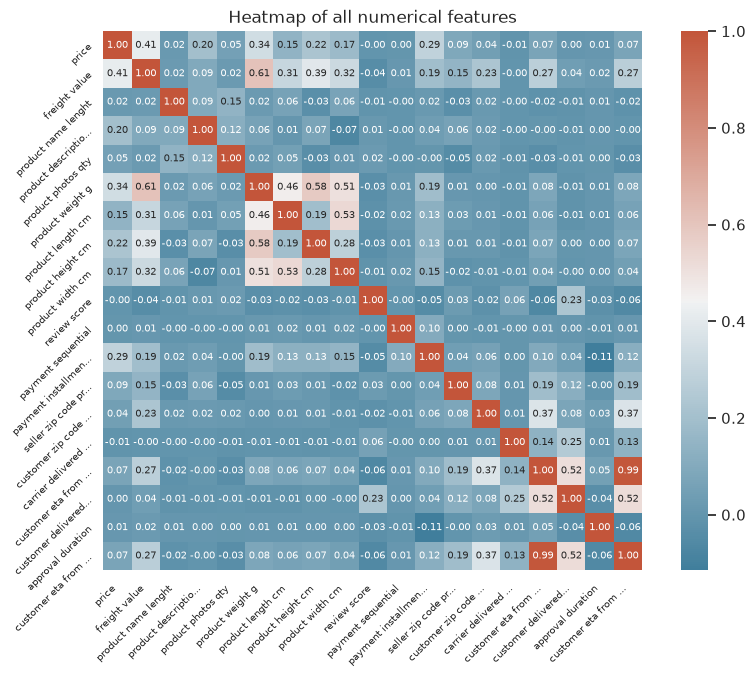

In [214]:
df_no_id = df1.drop(columns=['order_id', 'order_item_id', 'product_id', 'seller_id','customer_id','customer_unique_id','seller_id','review_id'])
corr = df_no_id.select_dtypes(include=[int, float, np.number]).corr()
# print(type(corr))
# ticklabels = ['price', 'freight value', '(product) desc length', '(product) photos qty', 'review score', '(payment) sequential', '(payment) instalments', 'seller zip code', 'customer zip code']
label = format_labels(list(df_no_id.select_dtypes(include=[int, float, np.number]).columns),short=True)

sns.set_theme(style="white")
cmap = sns.diverging_palette(230, 20, as_cmap=True)
# mask = np.triu(np.ones_like(corr, dtype=bool))

plt.figure(figsize=(10, 7))
sns.heatmap(corr, cmap=cmap, annot=True, fmt=".2f", square = True, annot_kws={'size': 7}, xticklabels=label, yticklabels=label)
plt.tick_params(axis='both', labelsize=7)
plt.yticks(va='center', rotation_mode='anchor', rotation=45)
plt.xticks(ha='left', rotation_mode='xtick', rotation=45)
plt.title('Heatmap of all numerical features')
plt.show()

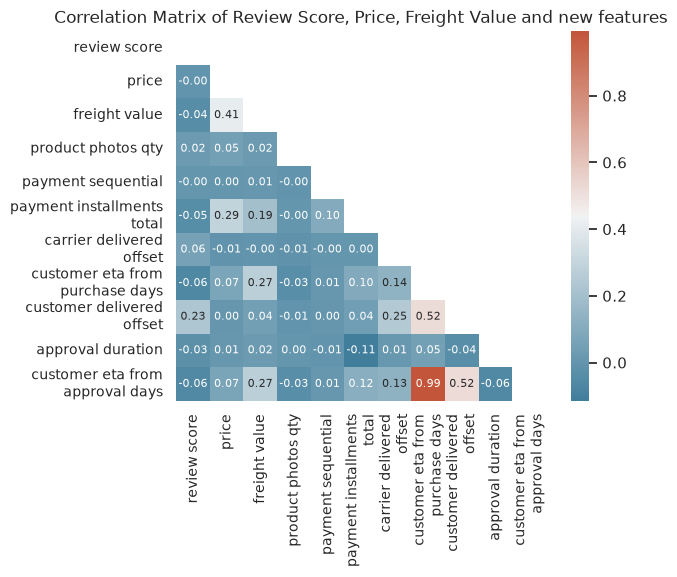

In [215]:
df_no_id = df1.drop(columns=['order_id', 'order_item_id', 'product_id', 'seller_id','customer_id','customer_unique_id','seller_id','review_id'])
df_reduced = df_no_id[['review_score','price','freight_value','product_photos_qty',
                       'payment_sequential','payment_installments_total',
                       'carrier_delivered_offset', 'customer_eta_from_purchase_days',
                       'customer_delivered_offset', 'approval_duration', 'customer_eta_from_approval_days']]
corr = df_reduced.corr()
# print(type(corr))
# ticklabels = ['price', 'freight value', '(product) desc length', '(product) photos qty', 'review score', '(payment) sequential', '(payment) instalments', 'seller zip code', 'customer zip code']
label = format_labels(list(df_reduced.columns))

sns.set_theme(style="white")
cmap = sns.diverging_palette(230, 20, as_cmap=True)
mask = np.triu(np.ones_like(corr, dtype=bool))

sns.heatmap(corr, cmap=cmap, annot=True, fmt=".2f",mask=mask, square = True, annot_kws={'size': 8}, xticklabels=label, yticklabels=label)
plt.tick_params(axis='both', labelsize=10)
plt.yticks(va='center', rotation_mode='anchor')
plt.xticks(ha='right', rotation_mode='xtick')
plt.title('Correlation Matrix of Review Score, Price, Freight Value and new features')
plt.show()

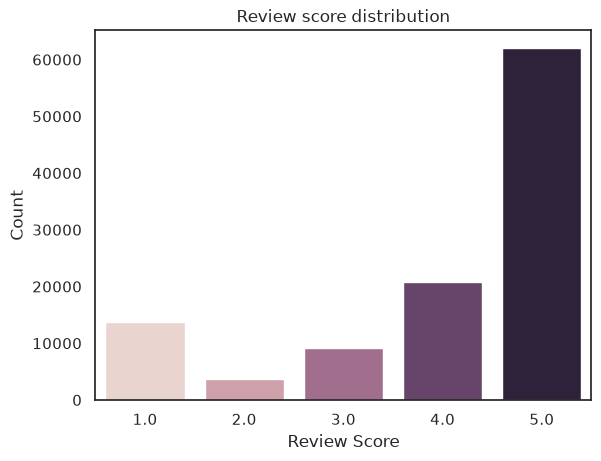

In [216]:
sns.countplot(data=df1, x='review_score', hue="review_score",legend=None)
plt.title('Review score distribution')
plt.xlabel('Review Score')
plt.ylabel('Count')
plt.show()

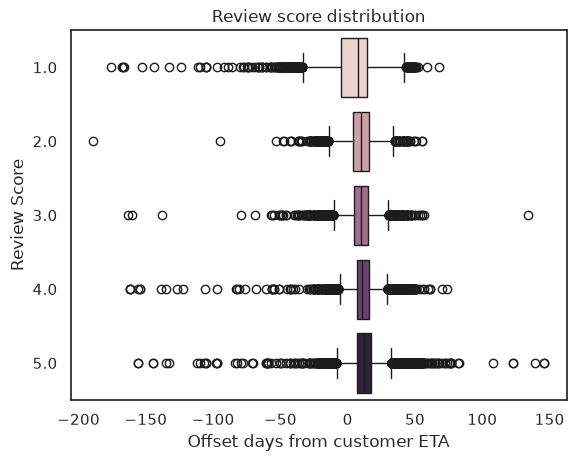

In [217]:
sns.boxplot(data=df1, x='customer_delivered_offset', y='review_score', orient='y',hue='review_score',legend=None)
plt.title('Review score distribution')
plt.ylabel('Review Score')
plt.xlabel('Offset days from customer ETA')
plt.show()

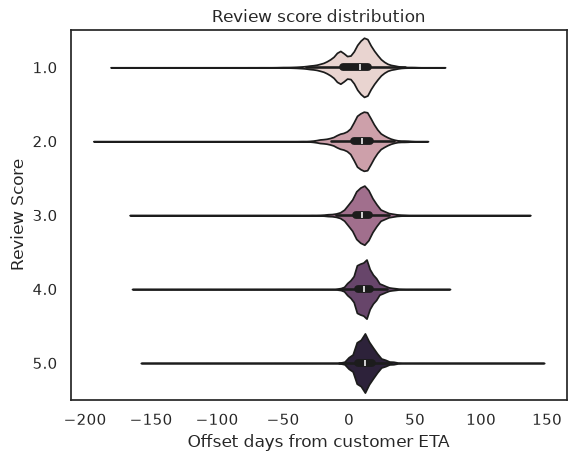

In [218]:
sns.violinplot(data=df1, x='customer_delivered_offset', y='review_score', orient='y',hue='review_score',legend=None)
plt.title('Review score distribution')
plt.ylabel('Review Score')
plt.xlabel('Offset days from customer ETA')
plt.show()

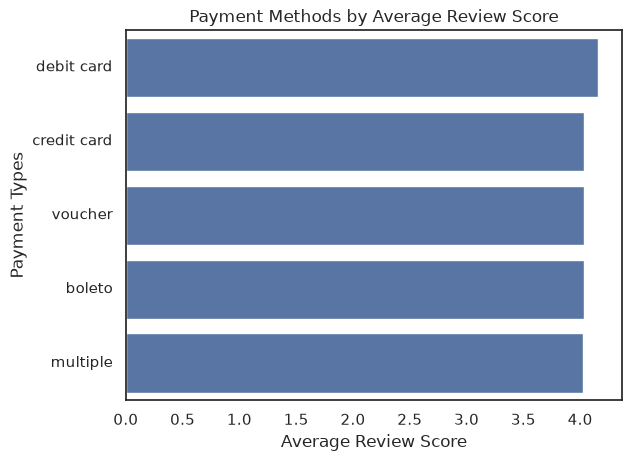

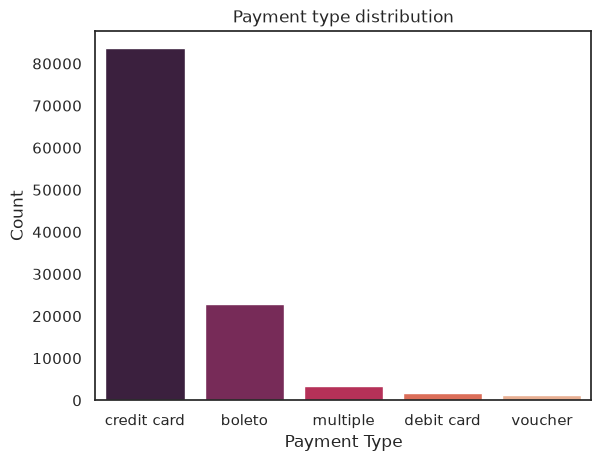

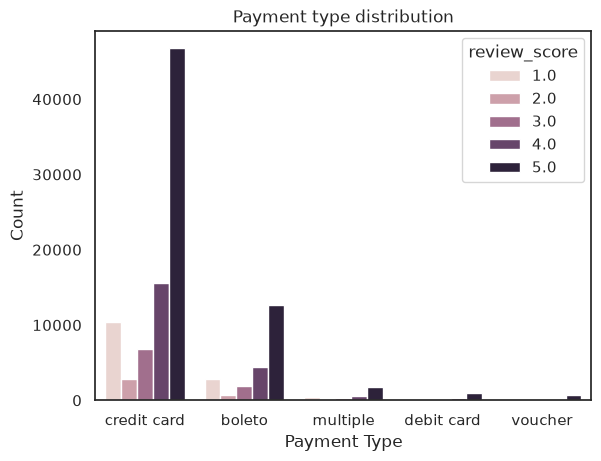

In [219]:
payment_type_score = df1.groupby('payment_type_all')['review_score'].mean().nlargest(10)
labels = list(payment_type_score.index)

sns.barplot(data=payment_type_score, orient='h')
plt.title('Payment Methods by Average Review Score')
plt.xlabel('Average Review Score')
plt.ylabel('Payment Types')
plt.yticks(labels, format_labels(labels), va='center', rotation_mode='anchor')
plt.show()

labels=df['payment_type_all'].unique().dropna()
sns.countplot(data=df, x='payment_type_all',hue='payment_type_all',legend=False,palette='rocket')
plt.title('Payment type distribution')
plt.xlabel('Payment Type')
plt.ylabel('Count')
plt.xticks(labels, format_labels(labels))
plt.show()

sns.countplot(data=df, x='payment_type_all',hue='review_score')
plt.title('Payment type distribution')
plt.xlabel('Payment Type')
plt.ylabel('Count')
plt.xticks(labels, format_labels(labels))
plt.show()

/tmp/ipykernel_6304/2918464753.py:6: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(data=cat_score_big,orient='h', palette='ocean',ax=axes[0])
/tmp/ipykernel_6304/2918464753.py:15: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(data=cat_score_small,orient='h', palette='ocean_r',ax=axes[1])


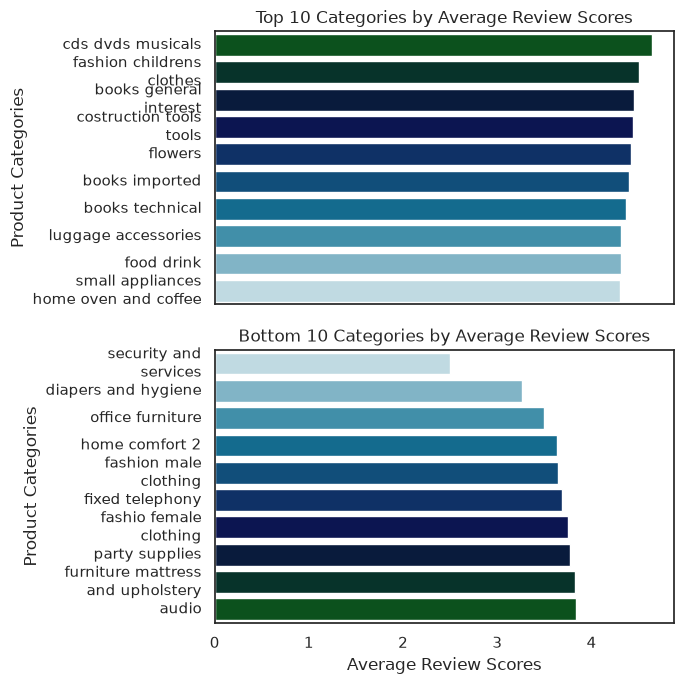

In [220]:
cat_score_big = df1.groupby('product_category_name_english')['review_score'].mean().nlargest(10)
labels = list(cat_score_big.index)

fig, axes = plt.subplots(2,1,figsize=(7,7),sharex=True)

sns.barplot(data=cat_score_big,orient='h', palette='ocean',ax=axes[0])
axes[0].set_title('Top 10 Categories by Average Review Scores')
axes[0].set_xlabel('Average Review Scores')
axes[0].set_ylabel('Product Categories')
axes[0].set_yticks(labels, format_labels(labels), va='center', rotation_mode='anchor')

cat_score_small = df1.groupby('product_category_name_english')['review_score'].mean().nsmallest(10)
labels = list(cat_score_small.index)

sns.barplot(data=cat_score_small,orient='h', palette='ocean_r',ax=axes[1])
axes[1].set_title('Bottom 10 Categories by Average Review Scores')
axes[1].set_xlabel('Average Review Scores')
axes[1].set_ylabel('Product Categories')
axes[1].set_yticks(labels, format_labels(labels), va='center', rotation_mode='anchor')

plt.tight_layout()
plt.show()

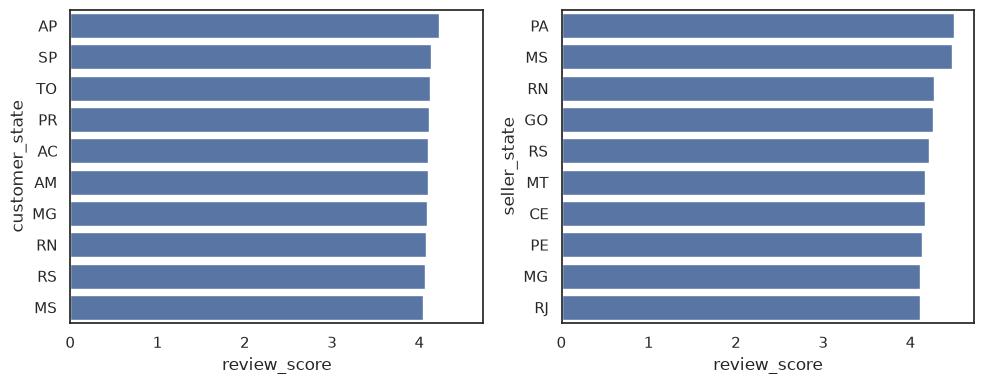

Index(['geolocation_zip_code_prefix', 'geolocation_lat', 'geolocation_lng',
       'geolocation_city', 'geolocation_state'],
      dtype='str')


In [221]:
cust_state_score = df1.groupby('customer_state')['review_score'].mean().nlargest(10)

fig, axes = plt.subplots(1, 2, figsize=(10, 4), sharex=True)

sns.barplot(data=cust_state_score,orient='h',ax=axes[0])
# axes[0].set_title('Top 10 States by Average Review Scores (Customer)')
# axes[0].set_xlabel('Review Score')
# axes[0].set_ylabel('Customer State')

seller_state_score = df1.groupby('seller_state')['review_score'].mean().nlargest(10)

sns.barplot(data=seller_state_score,orient='h',ax=axes[1])
# axes[1].set_title('Top 10 States by Average Review Scores (Seller)')
# axes[1].set_xlabel('Review Score')
# axes[1].set_ylabel('Seller State')

plt.tight_layout()
plt.show()
# geoplot for city and state?

print(olist['geolocation'].columns)

/tmp/ipykernel_6304/1971566540.py:4: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(data=order_status_score,orient='h', palette='viridis')


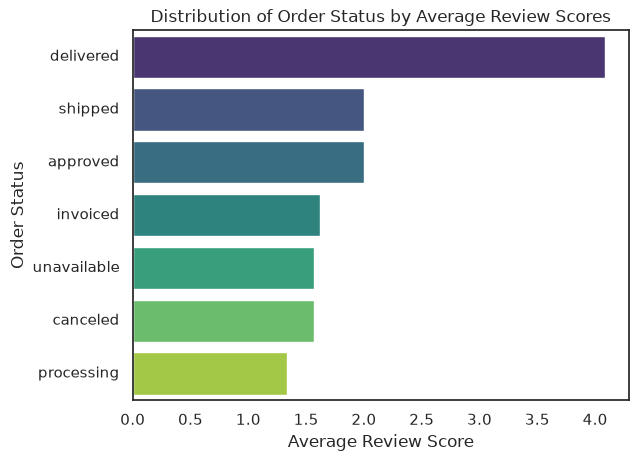

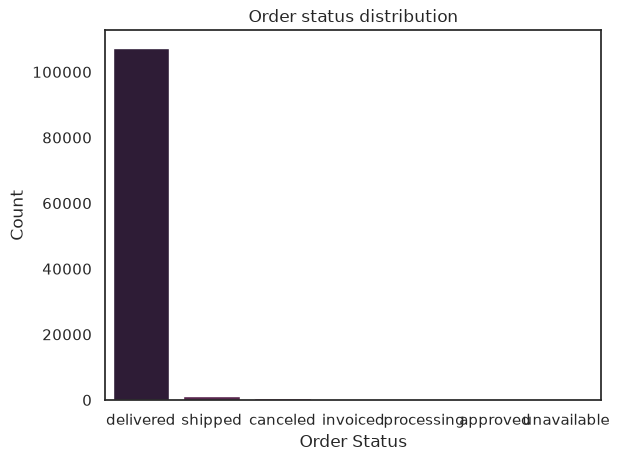

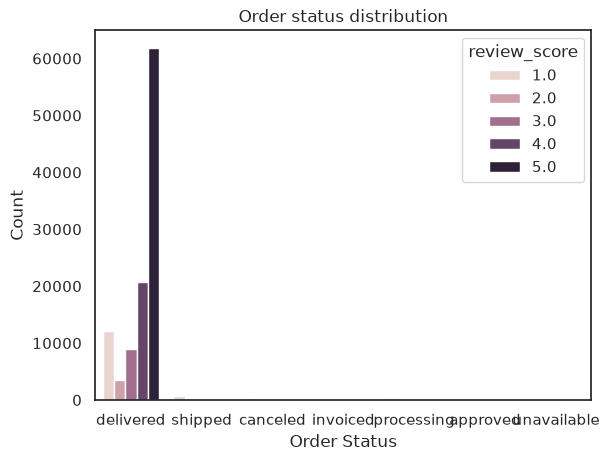

In [222]:
order_status_score = df1.groupby('order_status')['review_score'].mean().nlargest(10)
labels = list(order_status_score.index)

sns.barplot(data=order_status_score,orient='h', palette='viridis')
plt.title('Distribution of Order Status by Average Review Scores')
plt.xlabel('Average Review Score')
plt.ylabel('Order Status')
plt.yticks(labels, format_labels(labels), va='center', rotation_mode='anchor')
plt.show()

labels = df1['order_status'].unique().dropna()
sns.countplot(data=df1, x='order_status',hue='order_status',legend=False,palette='rocket')
plt.title('Order status distribution')
plt.xlabel('Order Status')
plt.ylabel('Count')
plt.xticks(labels, format_labels(labels))
plt.show()

sns.countplot(data=df1, x='order_status',hue='review_score')
plt.title('Order status distribution')
plt.xlabel('Order Status')
plt.ylabel('Count')
plt.xticks(labels, format_labels(labels))
plt.show()

In [223]:
# descriptor_col = ['review_comment_title', 'review_comment_message'] # graph about proportion of reviews with title/comment

# review_title_score = df.groupby('payment_type_all')['review_score'].mean().nlargest(10)
# labels = list(review_title_score.index)

# sns.barplot(data=review_title_score)
# # plt.title('Top 10 Categories by Average Review Scores')
# # plt.xlabel('Review')
# # plt.ylabel('Product Categories')
# # plt.yticks(labels, format_labels(labels), va='center', rotation_mode='anchor')
# plt.show()

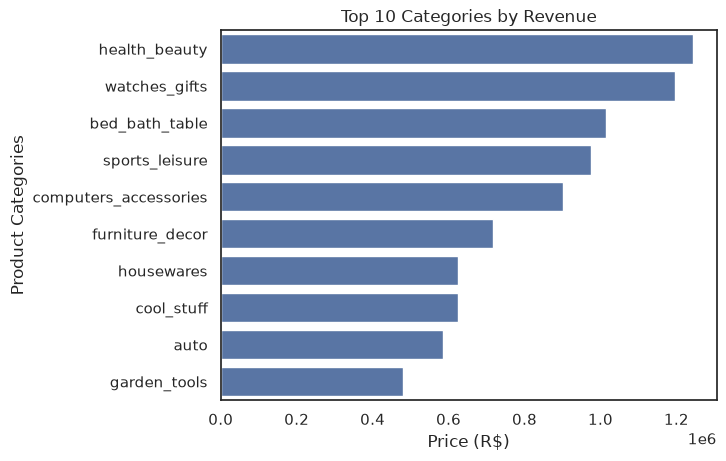

In [224]:
cat_revenue = df1.groupby('product_category_name_english')['price'].sum().nlargest(10)
sns.barplot(data=cat_revenue,orient='h',)
plt.title('Top 10 Categories by Revenue')
plt.xlabel('Price (R$)')
plt.ylabel('Product Categories')
plt.show()

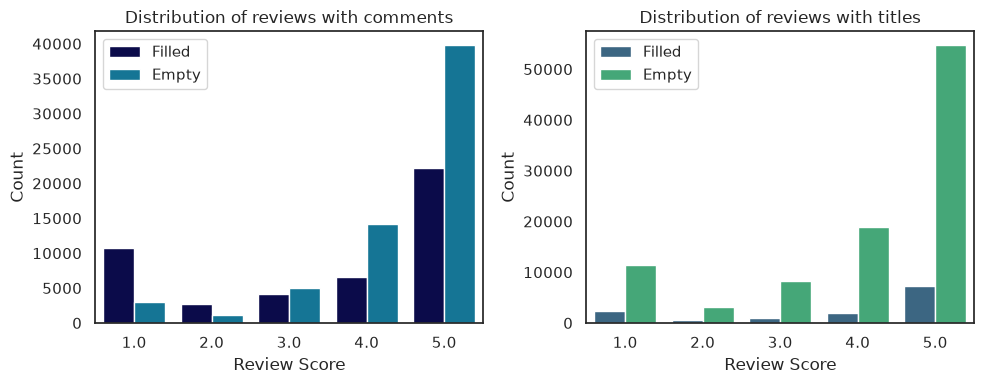

In [225]:
empty_reviews = pd.concat(
    [df1['review_id'],
     df1['review_score'],
     df1['review_comment_message'].isna().rename("empty_comment"),
     df1['review_comment_title'].isna().rename("empty_title")],
     axis=1
)
label = ['Filled', 'Empty']

fig, axes = plt.subplots(1, 2, figsize=(10, 4), sharex=True)

sns.countplot(data=empty_reviews,x='review_score', hue='empty_comment', palette='ocean',ax=axes[0])
axes[0].legend(labels = label)
axes[0].set_title('Distribution of reviews with comments')
axes[0].set_xlabel('Review Score')
axes[0].set_ylabel('Count')

sns.countplot(data=empty_reviews,x='review_score', hue='empty_title', palette='viridis',ax=axes[1])
axes[1].legend(labels=label)
axes[1].set_title('Distribution of reviews with titles')
axes[1].set_xlabel('Review Score')
axes[1].set_ylabel('Count')

plt.tight_layout()
plt.show()

In [226]:
# Column removals come after EDA
# remove_cols = ['product_name_lenght','product_description_lenght','product_photos_qty','product_weight_g','product_length_cm','product_height_cm','seller_zip_code_prefix','customer_zip_code_prefix']
# df1 = df1.drop(columns=remove_cols)
# print(f'Percentage of loss from removing columns: {len(remove_cols)} ({(len(df.columns)-len(df1.columns))/len(df.columns):.2%})')

In [227]:
df1.isna().sum()

order_id                               0
order_item_id                          0
product_id                             0
seller_id                              0
shipping_limit_date                    0
price                                  0
freight_value                          0
product_category_name                  0
product_name_lenght                    0
product_description_lenght             0
product_photos_qty                     0
product_weight_g                       0
product_length_cm                      0
product_height_cm                      0
product_width_cm                       0
product_category_name_english          0
customer_id                            0
order_status                           0
order_purchase_timestamp               0
order_approved_at                     14
order_delivered_carrier_date        1131
order_delivered_customer_date       2257
order_estimated_delivery_date          0
review_id                              0
review_score    

## MOVING

# Data Cleaning (after initial EDA) [col removal etc]

* very high class imbalance for review scores
* customer_delivered_offset has the highest correlation score (albeit not very strong)
* correlation matrix does not show any strong indicator for the data to lean one way or another
* order_status might have some relation
* no pattern found for payment_type
* pattern found for reviews with titles/comments? (how to argue for this...)

## Resolving Class Imbalances (data transformation/preprocessing!!)

## Choosing relevant features

## Final EDA

Split data into 80-20 (train-test) split, then do EDA on TRAIN data

In [228]:
# df_no_id = df.drop(columns=['order_id', 'order_item_id', 'product_id', 'seller_id','customer_id','customer_unique_id','seller_id','review_id'])
# corr = df_no_id.select_dtypes(include=[int, float, np.number]).corr()
# print(type(corr))
# # ticklabels = ['price', 'freight value', '(product) desc length', '(product) photos qty', 'review score', '(payment) sequential', '(payment) instalments', 'seller zip code', 'customer zip code']

# sns.set_theme(style="white")
# cmap = sns.diverging_palette(230, 20, as_cmap=True)

# sns.heatmap(corr, cmap=cmap, annot=True, fmt=".1f", square = True)
# plt.show()

# Data Model (output)

In [229]:
# import os
# # Save consolidated dataset

# output_path = "./olist_consolidated.csv"
# df.to_csv(output_path, index=False)
# print(f"✅ Saved consolidated dataset to: {output_path}")
# print(f"   Shape: {df.shape[0]:,} rows × {df.shape[1]} columns")
# print(f"   Size: {os.path.getsize(output_path) / 1e6:.2f} MB")

Explain 3 things here:
1. Key data tables used
2. Describe the consolidated dataset, how the key data tables are joined
3. Data loss and gain after EDA, cleaning, etc

# Baseline models

## Regression

## Classification